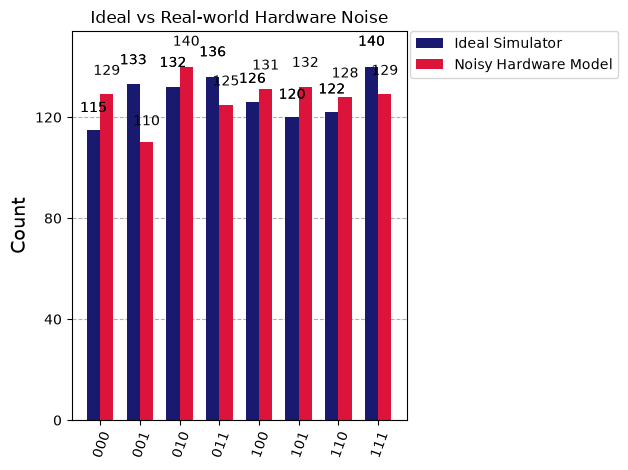

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

# 1. Same 3-qubit circuit
qc = QuantumCircuit(3, 3)
qc.h([0, 1, 2])
qc.measure([0, 1, 2], [0, 1, 2])

# 2. Setup the Ideal Simulator
ideal_sim = AerSimulator()
ideal_job = ideal_sim.run(transpile(qc, ideal_sim), shots=1024)
ideal_counts = ideal_job.result().get_counts()

# 3. Setup the Noisy Fake Backend (mimics real physical hardware)
fake_backend = FakeManilaV2()
noisy_sim = AerSimulator.from_backend(fake_backend)
noisy_job = noisy_sim.run(transpile(qc, noisy_sim), shots=1024)
noisy_counts = noisy_job.result().get_counts()

# 4. Compare Ideal vs Noisy Results
plot_histogram(
    [ideal_counts, noisy_counts],
    legend=['Ideal Simulator', 'Noisy Hardware Model'],
    color=['midnightblue', 'crimson'],
    title="Ideal vs Real-world Hardware Noise"
)